In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
pd.set_option('display.max_colwidth', 100)

In [3]:
df = pd.read_csv('../data/raw/complaints.csv', low_memory=False)
print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

Shape: (9609797, 18)

Columns: ['Date received', 'Product', 'Sub-product', 'Issue', 'Sub-issue', 'Consumer complaint narrative', 'Company public response', 'Company', 'State', 'ZIP code', 'Tags', 'Consumer consent provided?', 'Submitted via', 'Date sent to company', 'Company response to consumer', 'Timely response?', 'Consumer disputed?', 'Complaint ID']


In [4]:
df.head(3)

,Date received,Product,Sub-product,Issue,Sub-issue,Consumer complaint narrative,Company public response,Company,State,ZIP code,Tags,Consumer consent provided?,Submitted via,Date sent to company,Company response to consumer,Timely response?,Consumer disputed?,Complaint ID
0,2025-06-20,Credit reporting or other personal consumer reports,Credit reporting,Incorrect information on your report,Information belongs to someone else,NaN,NaN,Experian Information Solutions Inc.,FL,32092,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195687
1,2025-06-20,Debt collection,Telecommunications debt,Attempts to collect debt not owed,Debt is not yours,NaN,Company can't verify or dispute the facts in the complaint,"Eastern Account Systems of Connecticut, Inc.",FL,342XX,NaN,NaN,Web,2025-06-20,Closed with explanation,Yes,NaN,14195688
2,2025-06-20,Credit reporting or other personal consumer reports,Credit reporting,Improper use of your report,Reporting company used your report improperly,NaN,NaN,"TRANSUNION INTERMEDIATE HOLDINGS, INC.",AZ,85225,NaN,NaN,Web,2025-06-20,In progress,Yes,NaN,14195689


In [5]:
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
missing_df[missing_df['Missing Count'] > 0].sort_values('Missing %', ascending=False)

,Missing Count,Missing %
Tags,8981029,93.46
Consumer disputed?,8841498,92.01
Consumer complaint narrative,6629041,68.98
Company public response,4770207,49.64
Consumer consent provided?,1649561,17.17
Sub-issue,839522,8.74
Sub-product,235295,2.45
State,54516,0.57
ZIP code,30228,0.31
Issue,6,0.00


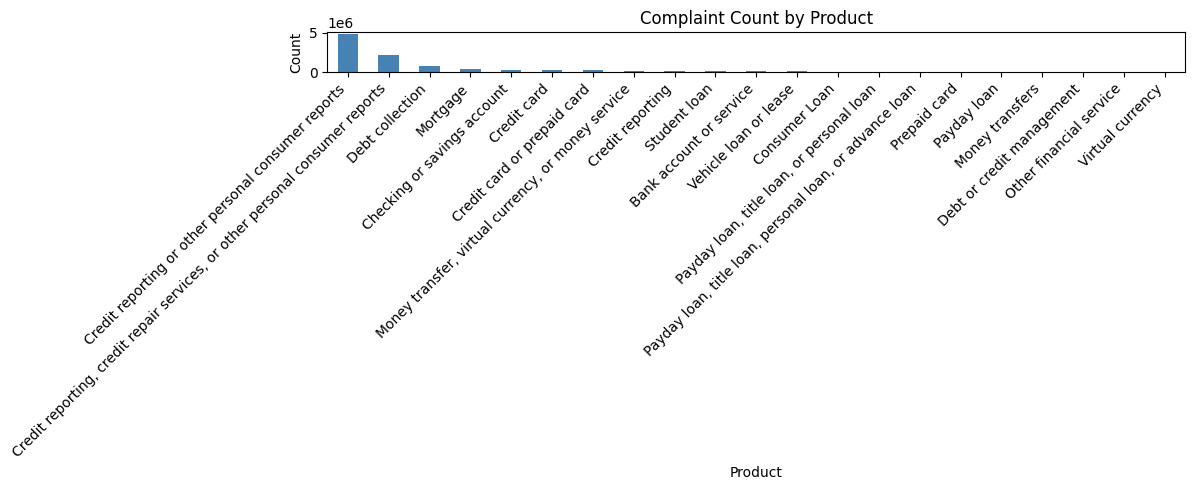

In [6]:
plt.figure(figsize=(12, 5))
df['Product'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Complaint Count by Product')
plt.xlabel('Product')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/processed/product_distribution.png')
plt.show()

In [7]:
target_products = [
    'Credit card',
    'Personal loan',
    'Savings account', 
    'Money transfers',
    'Credit card or prepaid card'
]

# Check which ones exist in your data
print("Products in dataset:")
print(df['Product'].unique())

Products in dataset:
['Credit reporting or other personal consumer reports' 'Debt collection'
 'Credit card' 'Checking or savings account'
 'Money transfer, virtual currency, or money service'
 'Vehicle loan or lease' 'Debt or credit management' 'Mortgage'
 'Payday loan, title loan, personal loan, or advance loan' 'Prepaid card'
 'Student loan' 'Credit reporting'
 'Credit reporting, credit repair services, or other personal consumer reports'
 'Credit card or prepaid card' 'Payday loan, title loan, or personal loan'
 'Bank account or service' 'Money transfers' 'Consumer Loan' 'Payday loan'
 'Other financial service' 'Virtual currency']


In [8]:
product_map = {
    'Credit card': 'Credit Cards',
    'Credit card or prepaid card': 'Credit Cards',
    'Payday loan, title loan, personal loan, or advance loan': 'Personal Loans',
    'Payday loan, title loan, or personal loan': 'Personal Loans',
    'Consumer Loan': 'Personal Loans',
    'Checking or savings account': 'Savings Accounts',
    'Bank account or service': 'Savings Accounts',
    'Money transfer, virtual currency, or money service': 'Money Transfers',
    'Money transfers': 'Money Transfers',
}

df_filtered = df[df['Product'].isin(product_map.keys())].copy()
df_filtered['product_clean'] = df_filtered['Product'].map(product_map)

print("Filtered shape:", df_filtered.shape)
print("\nCleaned product counts:")
print(df_filtered['product_clean'].value_counts())

Filtered shape: (1039587, 19)

Cleaned product counts:
product_clean
Credit Cards        433055
Savings Accounts    377383
Money Transfers     150420
Personal Loans       78729
Name: count, dtype: int64


In [9]:
# Find the narrative column (may vary by dataset)
narrative_cols = [c for c in df_filtered.columns if 'narrative' in c.lower()]
print("Narrative columns found:", narrative_cols)

# Check how many have actual text
for col in narrative_cols:
    filled = df_filtered[col].notna().sum()
    print(f"{col}: {filled} non-null ({filled/len(df_filtered)*100:.1f}%)")

Narrative columns found: ['Consumer complaint narrative']
Consumer complaint narrative: 478818 non-null (46.1%)


In [10]:
narrative_col = 'Consumer complaint narrative'  # adjust if Cell 8 shows different name

df_clean = df_filtered[df_filtered[narrative_col].notna()].copy()
df_clean = df_clean.rename(columns={narrative_col: 'narrative'})

print("After dropping empty narratives:", df_clean.shape)
print("\nProduct distribution in clean data:")
print(df_clean['product_clean'].value_counts())

After dropping empty narratives: (478818, 19)

Product distribution in clean data:
product_clean
Credit Cards        189334
Savings Accounts    155204
Money Transfers      98685
Personal Loans       35595
Name: count, dtype: int64


Narrative length stats:
       narrative_length     word_count
count     478818.000000  478818.000000
mean        1142.218492     205.808725
std         1252.238669     225.780011
min            4.000000       1.000000
25%          467.000000      83.000000
50%          753.000000     138.000000
75%         1403.000000     256.000000
max        32959.000000    6469.000000


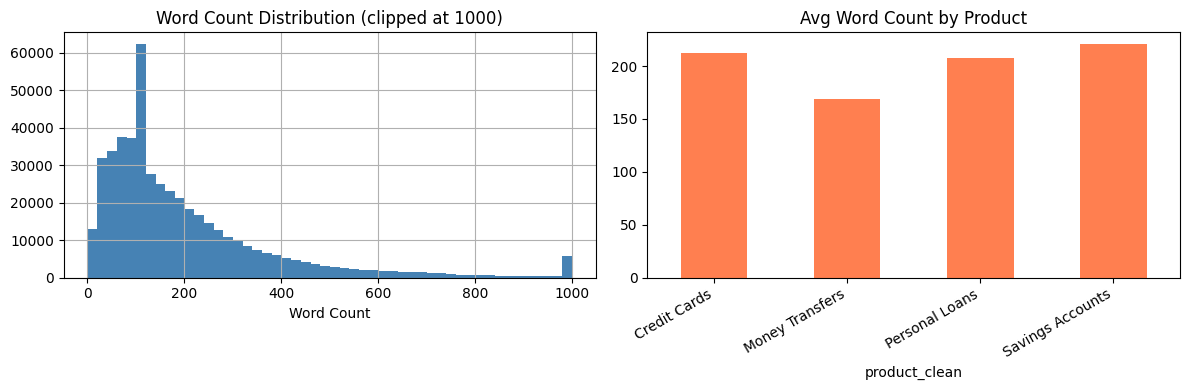

In [11]:
df_clean['narrative_length'] = df_clean['narrative'].str.len()
df_clean['word_count'] = df_clean['narrative'].str.split().str.len()

print("Narrative length stats:")
print(df_clean[['narrative_length', 'word_count']].describe())

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
df_clean['word_count'].clip(upper=1000).hist(bins=50, color='steelblue')
plt.title('Word Count Distribution (clipped at 1000)')
plt.xlabel('Word Count')

plt.subplot(1, 2, 2)
df_clean.groupby('product_clean')['word_count'].mean().plot(kind='bar', color='coral')
plt.title('Avg Word Count by Product')
plt.xticks(rotation=30, ha='right')

plt.tight_layout()
plt.savefig('../data/processed/narrative_length_analysis.png')
plt.show()

In [12]:
import re

def clean_text(text):
    if pd.isna(text):
        return ''
    # Remove boilerplate CFPB redaction tags
    text = re.sub(r'X{2,}', '', text)
    # Remove extra whitespace
    text = re.sub(r'\s+', ' ', text).strip()
    # Remove special characters but keep punctuation
    text = re.sub(r'[^\w\s\.,!?\'"-]', '', text)
    return text

df_clean['narrative_clean'] = df_clean['narrative'].apply(clean_text)

# Drop rows where cleaning left very short text
df_clean = df_clean[df_clean['narrative_clean'].str.len() > 50]

print("Final clean shape:", df_clean.shape)
print("\nSample cleaned narrative:")
print(df_clean['narrative_clean'].iloc[0][:300])

Final clean shape: (476693, 22)

Sample cleaned narrative:
A card was opened under my name by a fraudster. I received a notice from that an account was just opened under my name. I reached out to to state that this activity was unauthorized and not me. confirmed this was fraudulent and immediately closed the card. However, they have failed to remove this fr


In [13]:
# Select only needed columns
cols_to_keep = ['product_clean', 'narrative_clean', 'narrative_length', 'word_count']

# Add date if available
if 'Date received' in df_clean.columns:
    cols_to_keep.append('Date received')

df_final = df_clean[cols_to_keep].reset_index(drop=True)
df_final.columns = [c.lower().replace(' ', '_') for c in df_final.columns]

df_final.to_csv('../data/processed/complaints_cleaned.csv', index=False)
print("Saved to data/processed/complaints_cleaned.csv")
print("Final dataset shape:", df_final.shape)
df_final.head()

Saved to data/processed/complaints_cleaned.csv
Final dataset shape: (476693, 5)


,product_clean,narrative_clean,narrative_length,word_count,date_received
0,Credit Cards,A card was opened under my name by a fraudster. I received a notice from that an account was jus...,488,91,2025-06-13
1,Savings Accounts,I made the mistake of using my wellsfargo debit card to depsit funds Into ATM machine outside th...,555,109,2025-06-13
2,Credit Cards,"Dear CFPB, I have a secured credit card with citibank which is changed to unsecured card and I h...",806,156,2025-06-12
3,Credit Cards,"I have a Citi rewards cards. The credit balance issued to me was 8400.00. I recently moved, whic...",1199,233,2025-06-12
4,Credit Cards,b'I am writing to dispute the following charges on my CITI Credit Card Accounts where I have bec...,2908,454,2025-06-09
